# Assignment 1 – Customer Sales Analysis

## Problem Statement

Load a CSV file containing sales transactions using Pandas. Clean missing values, compute total revenue by product category, identify the top 10 customers, and visualize monthly sales using Matplotlib.




In [1]:
#import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
#load the dataset and view sample records

df = pd.read_csv('/content/sales.csv',encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
#check valueable info to see what the datatypes are for each column and see if there are any missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
#we see that there are no missing values here and verifiy it using this command
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [10]:
#to understand and show handling missing values, i have created a copy of the dataset and simulated the handling

df_demo = df.copy()

df_demo.loc[5,"Sales"] = np.nan
df_demo.loc[20,"Category"] = np.nan
df_demo.loc[50,"Customer Name"] = np.nan

In [16]:
df_demo.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,1
Segment,0
Country,0
City,0


In [21]:

#for simplicity we can directly/manually fill the NA values with mean for numeric and a text for categorical cols
print(df_demo["Sales"].mean())
df_demo["Sales"].fillna(df_demo["Sales"].mean(), inplace=True)
df_demo["Category"].fillna("Unknown", inplace=True)
df_demo["Customer Name"].fillna("Unknown", inplace=True)

229.87611330931654


In [23]:
#we can also use a generic way
num_col = df_demo.select_dtypes(include=['number']).columns
cat_col = df_demo.select_dtypes(include=['object']).columns

df_demo[num_col] = df_demo[num_col].fillna(df_demo[num_col].mean())
df_demo[cat_col] = df_demo[cat_col].fillna("unknown")

In [24]:
df_demo.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [25]:
#now store the cleaned dataset
df_demo.to_csv("./cleaned_sales.csv",index=False)

In [26]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [52]:
#Compute total sales revenue by each prodcut category

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales.columns = ["Category", "Total Revenue"]

category_sales

,Category,Total Revenue
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


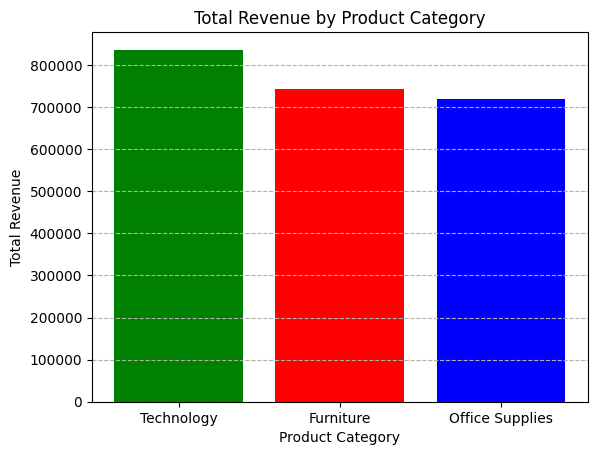

In [65]:
# A plot to show the total revenue of each prodcut category

plt.bar(
    category_sales["Category"],
    category_sales["Total Revenue"],
    color = ['g','r','b']
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.grid(axis="y", linestyle="--")

plt.show()


In [66]:
#To identify top 10 customers

top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_customers.columns = ["Customer Name", "Total Revenue"]

top_customers

,Customer Name,Total Revenue
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


In [69]:
#Monthly sales analysis

#converting the column to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Date'].head()

,Order Date
0,2016-11-08
1,2016-11-08
2,2016-06-12
3,2015-10-11
4,2015-10-11


In [70]:
# Extract month and year
df["Month"] = df["Order Date"].dt.to_period("M")
df[["Order Date", "Month"]].head()

,Order Date,Month
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


In [71]:
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Month"] = monthly_sales["Month"].astype(str)

monthly_sales

,Month,Sales
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


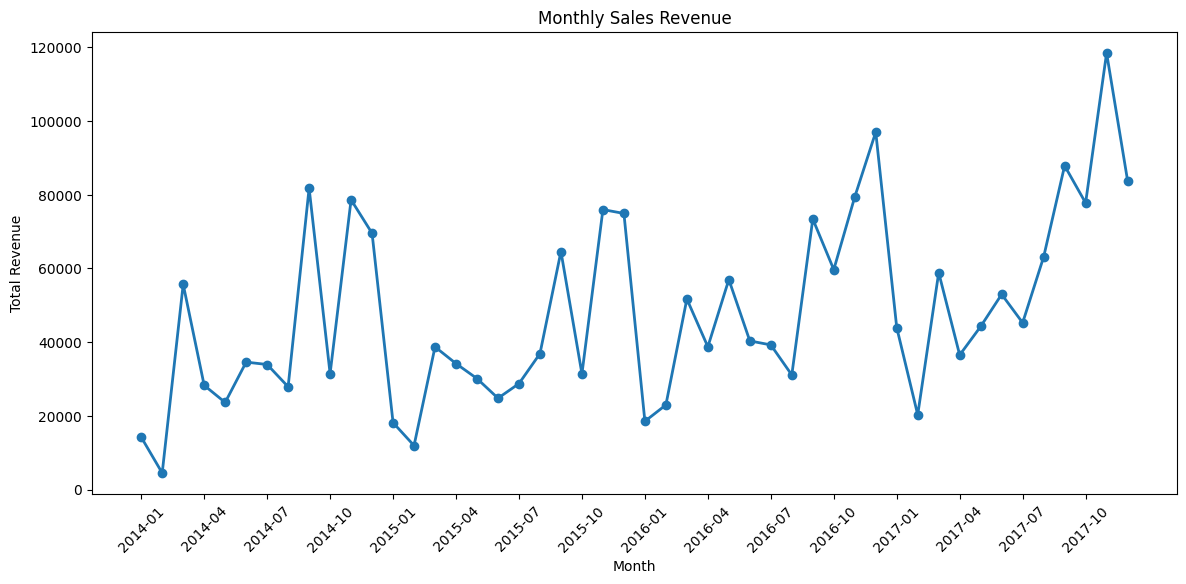

In [80]:
plt.figure(figsize=(14,6))


plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.xticks(
    ticks=range(0, len(monthly_sales), 3),
    labels=monthly_sales["Month"][::3],
    # rotation=45
)

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

## Observations

- The dataset contains 9,994 sales transaction records and no missing values were found.
- Technology generated the highest total revenue, followed by Furniture and Office Supplies.
- Sean Miller was the highest revenue-generating customer based on total sales.
- Monthly sales showed fluctuations over the four-year period, with higher sales observed during several year-end months.
- The analysis demonstrates how sales data can be summarized and visualized to identify customer and product category performance.